In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('../pysrc/')
from latexify import latexify

In [2]:
# From FIRE-3 Paper
a1 = 0.39
a2 = 0.51
a3 = 0.18
a4 = 0.0083

t1 = 3.7 # Myr
t2 = 7.0
t3 = 44.0

s1 = np.log(a2/a1)/np.log(t2/t1)
s2 = np.log(a3/a2)/np.log(t3/t2)
s3 = -1.1

print(s1,s2,s3)

0.42075521544182265 -0.5665372884829896 -1.1


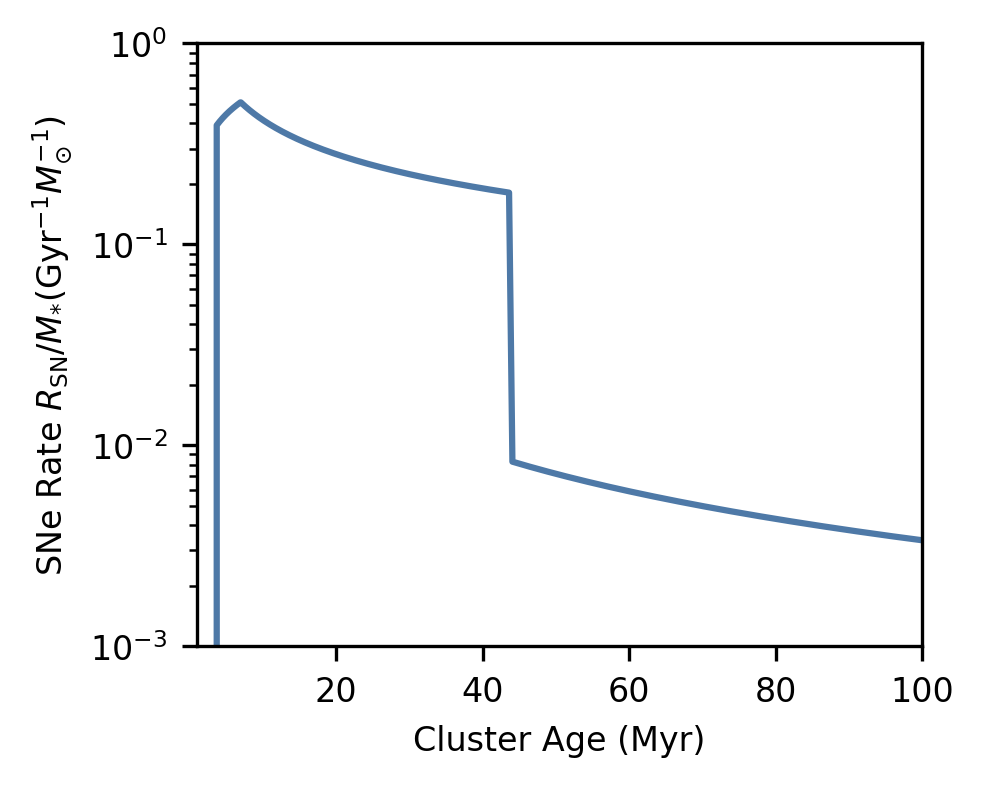

In [8]:
# rates, t in Myr
def rate(t):
    if (t < t1):
        return 0
    elif (t < t2):
        return a1*np.power(t/t1,s1)
    elif (t < t3):
        return a2*np.power(t/t2,s2)
    else:
        return a4*np.power(t/t3,s3)
    
t_range = np.logspace(0,4.5,1000)

latexify(columns=1)
plt.figure()
plt.plot(t_range, [rate(t) for t in t_range])
plt.yscale('log')
# plt.xscale('log')
plt.ylim([1e-3,1e0])
plt.xlim([1e0,1e2])

plt.ylabel(r'SNe Rate $R_{\rm SN}/M_{*} ({\rm Gyr}^{-1} M_{\odot}^{-1})$')
plt.xlabel('Cluster Age (Myr)')

plt.tight_layout()
plt.savefig('plots/sn_rate.pdf', dpi=300)
plt.show()


In [4]:
# t in gyr
def n_sn(t):
    if (t < t1):
        return 0
    elif (t <= t2):
        return ((a1*t1)/(s1+1))*(np.power(t/t1,s1+1)-1)/1000
    elif (t <= t3):
        return n_sn(t2) + ((a2*t2)/(s2+1))*(np.power(t/t2,s2+1)-1)/1000
    else:
        return n_sn(t3) + ((a4*t3)/(s3+1))*(np.power(t/t3,s3+1)-1)/1000
    
def n_sn_ia(t):
    if (t > t3):
        return ((a4*t3)/(s3+1))*(np.power(t/t3,s3+1)-1)/1000
    else: 
        return 0
    
def get_t_list(M,t_end):
    n1 = n_sn(t2)*M
    n2 = n_sn(t3)*M
    n_end = n_sn(t_end)*M
    
    # print(n1, n2, n_end)
   
    def get_sn_t(n):
        if (n < n1):
            return t1*np.power(((1000*n*(s1+1))/(M*a1*t1))+1,1/(s1+1))
        elif (n < n2):
            return t2*np.power(((1000*(n-n1)*(s2+1))/(M*a2*t2))+1,1/(s2+1))
        else:
            return t3*np.power(((1000*(n-n2)*(s3+1))/(M*a4*t3))+1,1/(s3+1))
    
    last_sn = np.floor(n_end)
    
    return np.array([get_sn_t(n) for n in np.arange(1,last_sn+1)])


# Testing
test_M = 1e6
sn_times = get_t_list(test_M,200)

# plt.figure()
# plt.plot(t_range, [test_M*n_sn(t) for t in t_range])
# plt.scatter(sn_times,[n+1 for n in range(len(sn_times))])
# plt.yscale('log')
# plt.xscale('log')
# plt.ylim([5e-5*test_M,2e-2*test_M])
# plt.xlim([1e0,1.5e4])
# plt.show()

dx = np.diff(sn_times)
print(np.min(dx)) # in Myr
print(np.min(dx)/100) # good, time steps are smaller than 4e-5

0.001960913798384034
1.960913798384034e-05
